# 3.2.5 B1 聚类原型可视化

## 目标
使用 3.2.4 B1 方法的预计算结果生成动态视频，展示每帧对应窗口的**阵型概率分布**和 TEI。

**方法说明**：
- B1 聚类原型方法：余弦相似度匹配 + 稳定性加权窗口聚合
- 输出：43 个 EFPI 阵型的概率分布（非预定义主流白名单）
- 可视化：显示 Top-6 概率最高的阵型

**⚠️ 依赖**：需先运行 3.2.4 生成 `b1_window_distributions.parquet` 和 `b1_mainstream_result.json`

## 1. 环境设置

In [1]:
import torch
import numpy as np
import polars as pl
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.animation import FFMpegWriter
from mplsoccer import Pitch
from datetime import timedelta
import pickle, json, warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
print('环境设置完成')

环境设置完成


## 2. 加载数据与 B1 预计算结果

In [2]:
# 路径配置
TEST_DIR = Path('.')
DATA_DIR = Path('../../../data/morph_test')

HOME_TEAM_ID = '364'  # 364=阿根廷, 363=法国

# 加载追踪数据
tracking_data = pl.read_parquet(DATA_DIR / 'tracking_data_10517_tactical_labels.parquet')
print(f'追踪数据: {tracking_data.shape}')

# 加载图数据集（过滤 NaN + 排序）
with open(DATA_DIR / 'bgnn_dataset/graph_dataset_10517_full.pkl', 'rb') as f:
    raw = pickle.load(f)
all_graphs = sorted([g for g in raw if not torch.isnan(g.x).any()],
                    key=lambda g: g.frame_id if isinstance(g.frame_id, int) else int(g.frame_id.item()))
print(f'图数据集: {len(all_graphs)} 帧（已过滤 NaN）')

# 加载 B1 预计算结果
b1_windows = pl.read_parquet(TEST_DIR / 'b1_window_distributions.parquet')
with open(TEST_DIR / 'b1_mainstream_result.json') as f:
    b1_result = json.load(f)

print(f'B1 窗口数: {b1_windows.shape[0]}')
print(f'主流阵型: {b1_result["mainstream"]}')
print(f'阈值: {b1_result["threshold"]}, 温度: {b1_result["tau"]}')

# EFPI：只保留阿根廷(364)的行，确保标签与主队一致
efpi_df = pl.read_parquet(DATA_DIR / "efpi_baseline/efpi_baseline_results_10517_fullmatch.parquet")
efpi_unique = (efpi_df
    .filter((pl.col("formation") != "ball") & (pl.col("team_id").cast(pl.Utf8) == HOME_TEAM_ID))
    .unique(subset=["frame_id"])
    .sort("frame_id")
)
fid_to_efpi = dict(zip(
    efpi_unique["frame_id"].to_list(),
    efpi_unique["formation"].to_list()
))
print(f"EFPI（阿根廷 team_id={HOME_TEAM_ID}）: {len(fid_to_efpi)} 帧")

追踪数据: (2966182, 25)
图数据集: 49928 帧（已过滤 NaN）
B1 窗口数: 662
主流阵型: ['442', '42121', '1234', '433', '3421', '2431']
阈值: 0.03, 温度: 0.07
EFPI（阿根廷 team_id=364）: 129368 帧


In [3]:
# 提取所有阵型列名
formation_cols = [c for c in b1_windows.columns if c.startswith('prob_')]
formations = [c.replace('prob_', '') for c in formation_cols]
n_formations = len(formations)

print(f'阵型数量: {n_formations}')
print(f'阵型列表: {formations[:10]}...')

# 创建 frame_id -> 窗口索引映射
fid_to_window = {}
for i, row in enumerate(b1_windows.iter_rows(named=True)):
    for fid in range(row['window_start'], row['window_end'] + 1):
        fid_to_window[fid] = i

# 创建 frame_id -> graph 索引映射
fid_to_idx = {}
for idx, g in enumerate(all_graphs):
    fid = g.frame_id if isinstance(g.frame_id, int) else int(g.frame_id.item())
    fid_to_idx[fid] = idx

print(f'窗口映射帧数: {len(fid_to_window)}')
print(f'图索引映射帧数: {len(fid_to_idx)}')
print(f'帧范围: {min(fid_to_window.keys())} - {max(fid_to_window.keys())}')

阵型数量: 43
阵型列表: ['1234', '1324', '1423', '1432', '2233', '2332', '2413', '2422', '2431', '31213']...
窗口映射帧数: 49876
图索引映射帧数: 49928
帧范围: 0 - 49875


## 3. 推理函数

In [4]:
def get_frame_distribution(frame_id):
    """获取指定帧的阵型概率分布、TEI、Dirichlet 后验方差、GM-TEI 指标"""
    if frame_id not in fid_to_window:
        return None, None, None, None, None, None, None

    window_idx = fid_to_window[frame_id]
    row = b1_windows.row(window_idx, named=True)

    probs    = np.array([row[c] for c in formation_cols])
    tei      = row['tei']

    # Dirichlet 后验方差（误差棒）
    probvar_cols = [c.replace('prob_', 'probvar_') for c in formation_cols]
    probs_var = np.array([row.get(c, 0.0) for c in probvar_cols])

    # GM-TEI 指标（来自 3.2.4）
    gm_tei_ab = row.get('gm_tei_ab', None)
    gm_tei_cb = row.get('gm_tei_cb', None)
    tac_dir   = row.get('tac_dir',   None)

    return probs, tei, formations, probs_var, gm_tei_ab, gm_tei_cb, tac_dir

print('get_frame_distribution: 返回值新增 gm_tei_ab / gm_tei_cb / tac_dir')


get_frame_distribution: 返回值新增 gm_tei_ab / gm_tei_cb / tac_dir


## 4. 可视化函数

In [5]:
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec

_prev_rankings = {}
HOME_TEAM = '364'

def visualize_frame(frame_id, probs, tei, ax_pitch, ax_bar, smooth_alpha=0.3,
                    probs_var=None, gm_tei_ab=None, gm_tei_cb=None, tac_dir=None):
    """
    可视化 v3：
    ① 细条形 + CI 误差棒置于条形正下方（半透明）
    ② 底部 0%~100% 参考刻度尺
    ③ 右下角显示 TacDir / GM-TEI_AB / GM-TEI_CB / TEI（从上到下）
    """
    global _prev_rankings

    frame_data = tracking_data.filter(pl.col('frame_id') == frame_id)
    home_data  = frame_data.filter((pl.col('team_id').cast(pl.Utf8) == HOME_TEAM) & (pl.col('position_name') != 'GK'))

    # ========== 球场面板 ==========
    ax_pitch.clear()
    X_MIN, X_MAX, Y_MIN, Y_MAX = -52.5, 52.5, -34, 34
    ax_pitch.set_xlim(X_MIN - 3, X_MAX + 3)
    ax_pitch.set_ylim(Y_MIN - 5, Y_MAX + 3)
    ax_pitch.set_aspect("equal")
    ax_pitch.axis("off")

    ax_pitch.add_patch(patches.Rectangle((X_MIN-5, Y_MIN-5), 115, 78, lw=0, fc="#3DA742", zorder=0))
    ax_pitch.add_patch(patches.Rectangle((X_MIN, Y_MIN), 105, 68, lw=2, ec="white", fc="none", zorder=1))
    ax_pitch.plot([0, 0], [Y_MIN, Y_MAX], "w-", lw=2, zorder=1)
    ax_pitch.add_patch(patches.Circle((0, 0), 9.15, lw=2, ec="white", fc="none", zorder=1))
    ax_pitch.plot(0, 0, "wo", ms=6, zorder=1)
    for sx, sign in [(X_MIN, 1), (X_MAX, -1)]:
        ax_pitch.add_patch(patches.Rectangle((sx, -20.16), sign*16.5, 40.32, lw=2, ec="white", fc="none", zorder=1))
        ax_pitch.add_patch(patches.Rectangle((sx, -9.16),  sign*5.5,  18.32, lw=2, ec="white", fc="none", zorder=1))
        ax_pitch.plot(sx + sign*11, 0, "wo", ms=5, zorder=1)

    if len(home_data) > 0 and frame_id in fid_to_idx:
        g  = all_graphs[fid_to_idx[frame_id]]
        if hasattr(g, 'edge_index') and g.edge_index is not None:
            px, py = home_data['x'].to_numpy(), home_data['y'].to_numpy()
            ei = g.edge_index.numpy()
            n_nodes = min(g.x.shape[0], len(px))
            for j in range(ei.shape[1]):
                u, v = ei[0, j], ei[1, j]
                if u < n_nodes and v < n_nodes:
                    ax_pitch.plot([px[u], px[v]], [py[u], py[v]], 'k-', alpha=0.5, zorder=2, lw=1.2)

    if len(home_data) > 0:
        for row in home_data.iter_rows(named=True):
            ax_pitch.add_patch(patches.Circle((row['x'], row['y']), 1.4, fc="#75AADB", ec="white", lw=1.5, zorder=3))

    ts_row   = frame_data.filter(pl.col('team_id').cast(pl.Utf8) == HOME_TEAM)
    ts_val   = ts_row['timestamp'][0] if len(ts_row) > 0 else None
    time_str = f'{int(ts_val.total_seconds()//60):02d}:{int(ts_val.total_seconds()%60):02d}' if ts_val else '--:--'
    mp       = frame_data['macro_phase'][0] if 'macro_phase' in frame_data.columns and len(frame_data) > 0 else ''
    fi       = frame_data['fine_intent'][0]  if 'fine_intent'  in frame_data.columns and len(frame_data) > 0 else ''
    period_id= frame_data['period_id'][0]    if 'period_id'    in frame_data.columns and len(frame_data) > 0 else '-'

    efpi_form = fid_to_efpi.get(frame_id, "--")
    header    = f"Frame {frame_id}   Half: {period_id}   {time_str}   |   EFPI: {efpi_form}\nArgentina - {mp}   {fi}"
    ax_pitch.text(0, Y_MAX + 2, header, ha='center', va='bottom', fontsize=11, fontweight='bold',
                  bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.9))

    # ========== 概率条形图面板 ==========
    ax_bar.clear()
    ax_bar.set_facecolor("#F5F5F5")
    ax_bar.axis("off")

    TOP_N        = min(7, len(probs))
    sorted_idx   = np.argsort(probs)[::-1][:TOP_N]
    sorted_names = [formations[i] for i in sorted_idx]
    sorted_probs = probs[sorted_idx]

    bar_colors         = ["#1565C0", "#1976D2", "#2196F3", "#42A5F5", "#64B5F6", "#90CAF9", "#BBDEFB"]
    bar_height         = 0.040
    ci_gap             = 0.008
    target_y_positions = [0.88, 0.76, 0.64, 0.52, 0.40, 0.28, 0.16]

    current_y_positions = []
    for k, formation_name in enumerate(sorted_names):
        target_y = target_y_positions[k]
        if formation_name in _prev_rankings:
            prev_y   = _prev_rankings[formation_name]
            smooth_y = prev_y * smooth_alpha + target_y * (1 - smooth_alpha)
        else:
            smooth_y = target_y
        current_y_positions.append(smooth_y)

    _prev_rankings = {name: y for name, y in zip(sorted_names, current_y_positions)}

    bar_start = 0.12
    for k in range(len(sorted_idx)):
        p    = sorted_probs[k]
        name = sorted_names[k]
        y    = current_y_positions[k]

        ax_bar.text(0.02, y, name, ha="left", va="center", fontsize=11, fontweight='bold',
                    transform=ax_bar.transAxes, zorder=3)

        bar_w = p * 0.50
        ax_bar.add_patch(patches.FancyBboxPatch(
            (bar_start, y - bar_height/2), max(bar_w, 0.002), bar_height,
            boxstyle='round,pad=0.003', fc=bar_colors[k], ec='none',
            transform=ax_bar.transAxes, zorder=2
        ))

        ax_bar.text(bar_start + bar_w + 0.012, y, f"{p*100:.1f}%",
                    ha="left", va="center", fontsize=10,
                    transform=ax_bar.transAxes, zorder=3)

        if probs_var is not None:
            var_k    = float(probs_var[sorted_idx[k]])
            ci_half  = 1.96 * np.sqrt(max(var_k, 0.0)) * 0.50
            x_center = bar_start + bar_w
            y_ci     = y - bar_height / 2 - ci_gap
            cap_h    = 0.007
            kw = dict(color='#37474F', lw=1.5, alpha=0.55,
                      transform=ax_bar.transAxes, zorder=5)
            ax_bar.plot([x_center - ci_half, x_center + ci_half], [y_ci, y_ci], **kw)
            ax_bar.plot([x_center - ci_half]*2, [y_ci - cap_h, y_ci + cap_h], **kw)
            ax_bar.plot([x_center + ci_half]*2, [y_ci - cap_h, y_ci + cap_h], **kw)

    # ③ 底部参考刻度尺
    y_ref = 0.045
    ax_bar.plot([bar_start, bar_start + 0.50], [y_ref, y_ref],
                color='#90A4AE', lw=1.2, transform=ax_bar.transAxes, zorder=1)
    for pct, label in [(0.00, '0%'), (0.25, '25%'), (0.50, '50%'), (0.75, '75%'), (1.00, '100%')]:
        xp = bar_start + pct * 0.50
        ax_bar.plot([xp, xp], [y_ref - 0.008, y_ref + 0.008],
                    color='#90A4AE', lw=1.2, transform=ax_bar.transAxes, zorder=1)
        ax_bar.text(xp, y_ref - 0.014, label, ha='center', va='top', fontsize=7,
                    color='#78909C', transform=ax_bar.transAxes)
    ax_bar.text(bar_start - 0.01, y_ref + 0.018, 'Scale', ha='right', va='center',
                fontsize=7, color='#78909C', transform=ax_bar.transAxes)

    # 标题与注释
    ax_bar.text(0.02, 0.99, 'B1 Formation Probability (Window-Level)',
                ha='left', va='top', fontsize=11, fontweight='bold', transform=ax_bar.transAxes)
    if probs_var is not None:
        ax_bar.text(0.02, 0.94, '误差棒 = Dirichlet 后验 95% CI（条形下方，半透明）',
                    ha='left', va='top', fontsize=8, color='#546E7A', transform=ax_bar.transAxes)

    # ③ 右下角：TEI + GM-TEI_AB + GM-TEI_CB + TacDir（从下往上堆叠）
    # ── TEI（最底层，红色，粗体）──────────────────────────────────────────────
    ax_bar.text(0.98, 0.08, f"TEI = {tei:.2f} bits", ha='right', va='bottom',
                fontsize=11, fontweight='bold', color='#D32F2F',
                transform=ax_bar.transAxes)

    # ── GM-TEI_CB ─────────────────────────────────────────────────────────────
    if gm_tei_cb is not None:
        gm_cb_val = float(gm_tei_cb)
        cb_color  = "#E65100" if gm_cb_val >= 0 else "#1565C0"
        ax_bar.text(0.98, 0.15, f"GM-TEI$_{{CB}}$ = {gm_cb_val:+.2f}",
                    ha='right', va='bottom', fontsize=9.5, color=cb_color,
                    transform=ax_bar.transAxes)

    # ── GM-TEI_AB ─────────────────────────────────────────────────────────────
    if gm_tei_ab is not None:
        gm_ab_val = float(gm_tei_ab)
        ab_color  = "#E65100" if gm_ab_val >= 0 else "#1565C0"
        ax_bar.text(0.98, 0.22, f"GM-TEI$_{{AB}}$ = {gm_ab_val:+.2f}",
                    ha='right', va='bottom', fontsize=9.5, color=ab_color,
                    transform=ax_bar.transAxes)

    # ── TacDir（最顶层，带方向符号）──────────────────────────────────────────
    if tac_dir is not None:
        td = int(round(float(tac_dir)))
        if td > 0:
            td_text, td_color = "▲ ATTACKING", "#2E7D32"
        elif td < 0:
            td_text, td_color = "▼ DEFENSIVE", "#1565C0"
        else:
            td_text, td_color = "■ NEUTRAL",   "#757575"
        ax_bar.text(0.98, 0.29, td_text, ha='right', va='bottom',
                    fontsize=9, fontweight='bold', color=td_color,
                    transform=ax_bar.transAxes)

print('visualize_frame v3：右下角新增 TacDir / GM-TEI_AB / GM-TEI_CB 显示')


visualize_frame v3：右下角新增 TacDir / GM-TEI_AB / GM-TEI_CB 显示


## 5. 单帧测试

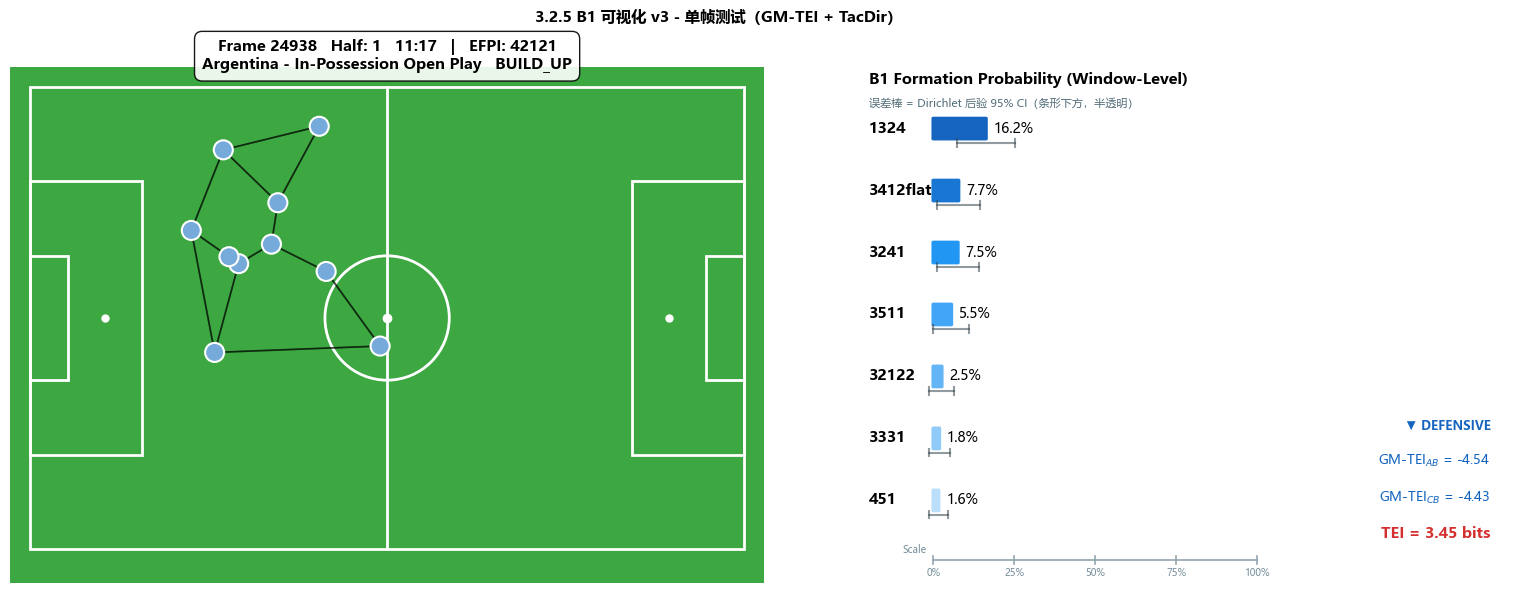

单帧测试完成: Frame 24938
TEI=3.445 bits   GM-TEI_AB=-4.544   GM-TEI_CB=-4.432   TacDir=-1
  1324: 16.2%  ±9.0% (95%CI)
  3412flat: 7.7%  ±6.5% (95%CI)
  3241: 7.5%  ±6.5% (95%CI)


In [6]:
OUTPUT_DIR = Path('../../../data/morph_test/bgnn_visualization')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

_prev_rankings = {}

valid_frames = sorted(fid_to_window.keys())
test_frame   = valid_frames[len(valid_frames) // 2]
probs_t, tei_t, _, probs_var_t, gm_ab_t, gm_cb_t, tac_t = get_frame_distribution(test_frame)

if probs_t is not None:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={'width_ratios': [1.4, 1]})
    visualize_frame(test_frame, probs_t, tei_t, ax1, ax2, probs_var=probs_var_t,
                    gm_tei_ab=gm_ab_t, gm_tei_cb=gm_cb_t, tac_dir=tac_t)
    plt.suptitle('3.2.5 B1 可视化 v3 - 单帧测试（GM-TEI + TacDir）',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'b1_single_frame.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'单帧测试完成: Frame {test_frame}')
    print(f'TEI={tei_t:.3f} bits   GM-TEI_AB={gm_ab_t:+.3f}   GM-TEI_CB={gm_cb_t:+.3f}   TacDir={int(tac_t) if tac_t is not None else None}')
    top3 = np.argsort(probs_t)[::-1][:3]
    for i in top3:
        std_i = np.sqrt(probs_var_t[i])
        print(f'  {formations[i]}: {probs_t[i]*100:.1f}%  ±{1.96*std_i*100:.1f}% (95%CI)')
else:
    print(f'Frame {test_frame} 不在窗口映射中')


## 6. 生成视频

In [7]:
START_TIME = 11 * 60 + 30
END_TIME   = 12 * 60 + 2

print('获取时间戳...')
frame_ts = {}
for fid in fid_to_window.keys():
    fd = tracking_data.filter(pl.col('frame_id') == fid)
    if len(fd) > 0:
        ts = fd['timestamp'][0]
        frame_ts[fid] = ts.total_seconds() if isinstance(ts, timedelta) else float(ts)

video_frame_ids = sorted([fid for fid, t in frame_ts.items() if START_TIME <= t <= END_TIME])
print(f'视频帧数: {len(video_frame_ids)}')
if len(video_frame_ids) > 0:
    print(f'帧ID范围: {video_frame_ids[0]} - {video_frame_ids[-1]}')
    FPS = 30000 / 1001
    print(f'预计时长: {len(video_frame_ids)/FPS:.1f} 秒')

print('预计算推理...')
precomp = {}
for fid in video_frame_ids:
    probs, tei, _, probs_var, gm_ab, gm_cb, tac = get_frame_distribution(fid)
    if probs is not None:
        precomp[fid] = (probs, tei, probs_var, gm_ab, gm_cb, tac)

print(f'有效帧: {len(precomp)}')


获取时间戳...
视频帧数: 959
帧ID范围: 25310 - 26268
预计时长: 32.0 秒
预计算推理...
有效帧: 959


In [8]:
if len(precomp) > 0:
    _prev_rankings = {}

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={'width_ratios': [1.4, 1]})

    def update(frame_idx):
        fid = video_frame_ids[frame_idx]
        if fid in precomp:
            probs, tei, probs_var, gm_ab, gm_cb, tac = precomp[fid]
            visualize_frame(fid, probs, tei, ax1, ax2, smooth_alpha=0.3,
                            probs_var=probs_var, gm_tei_ab=gm_ab, gm_tei_cb=gm_cb, tac_dir=tac)
        return fig,

    from matplotlib.animation import FuncAnimation
    anim = FuncAnimation(fig, update, frames=len(video_frame_ids), interval=1000/FPS, blit=False)

    video_path = OUTPUT_DIR / 'b1_visualization_10517_segment.mp4'
    writer = FFMpegWriter(fps='30000/1001', bitrate=2000)
    print(f'保存视频: {video_path}')
    anim.save(str(video_path), writer=writer, dpi=100)
    plt.close()
    print(f'视频生成完成！时长: {len(video_frame_ids)/FPS:.1f} 秒')
else:
    print('无有效帧，跳过视频生成')


保存视频: ..\..\..\data\morph_test\bgnn_visualization\b1_visualization_10517_segment.mp4
视频生成完成！时长: 32.0 秒


## 7. 总结

**B1 方法输出**：
- 阵型数量：43 个（实际出现的 EFPI 阵型）
- 可视化：Top-6 概率最高的阵型
- TEI 范围：约 2.2-2.8 nats（窗口级熵）

**输出文件**：
- `bgnn_visualization/b1_single_frame.png`：单帧测试
- `bgnn_visualization/b1_visualization.mp4`：动态视频

**下一步**：
- 运行 3.2.6（TEI 统计分析）
- 运行 3.2.7（变化点检测）
- 创建 3.3（评估对比）